# Data Augmentation Comparison

This notebook summarizes the adaptive data augmentation experiment for thesis-ready reporting. It uses the posthoc checkpoint evaluation as the primary source for external ID/OOD metrics, replacing the exploratory notebook's earlier held-out-test substitute for ID accuracy.

Pipeline script: `src/experiments/pipeline/run_data_augmentation_comparison.py`  
Raw outputs: `outputs/data_augmentation_comparison/`  
Table exports: `results/tables/06_data_augmentation/`

## Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import sys


def _find_repo_root(start: Path | None = None) -> Path:
    start = (Path.cwd() if start is None else start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir():
            if str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
            return candidate
    raise FileNotFoundError(f"Could not find repository root from {start}")

REPO = _find_repo_root()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.visualization.results_helpers import (
    aggregate_mean_sem,
    epoch_metrics_path,
    ensure_repo_root_on_path,
    load_json,
    load_posthoc_external_eval,
    mean_sem_text,
    overlay_posthoc_external_eval,
    read_epoch_metrics,
)
from results.notebook_utils import table_dir, write_table, write_numeric_table

from src.visualization.thesis_style import (
    DTU_COLORS,
    NEUTRAL_COLORS,
    apply_thesis_axis_style,
    log_minor_grid,
    save_figure,
    set_thesis_style,
)

REPO = ensure_repo_root_on_path(REPO)
ROOT = REPO / "outputs" / "data_augmentation_comparison"
# Scratch export directory is intentionally not created for repository submission.
TABLE_EXPORT = table_dir("data_augmentation")

set_thesis_style()

SUPERVISED_ORDER = ["fixed_low", "random_growth", "mae_nearest_growth", "fixed_final"]
COLLOCATION_ORDER = ["static_low", "rar_d_growth"]
EXPECTED_SEEDS = ["s01", "s02", "s03"]

SUPERVISED_LABEL = {
    "fixed_low": "fixed 256",
    "random_growth": "random growth",
    "mae_nearest_growth": "MAE-nearest growth",
    "fixed_final": "fixed 512",
}
COLLOCATION_LABEL = {
    "static_low": "static 4k",
    "rar_d_growth": "RAR-D growth",
}
SUPERVISED_COLOR = {
    "fixed_low": NEUTRAL_COLORS["muted"],
    "random_growth": DTU_COLORS["blue"],
    "mae_nearest_growth": DTU_COLORS["corporate_red"],
    "fixed_final": DTU_COLORS["green"],
}
COLLOCATION_MARKER = {"static_low": "o", "rar_d_growth": "s"}
COLLOCATION_STYLE = {"static_low": "--", "rar_d_growth": "-"}


def supervised_label(value: str) -> str:
    return SUPERVISED_LABEL.get(str(value), str(value))


def collocation_label(value: str) -> str:
    return COLLOCATION_LABEL.get(str(value), str(value))


def ordered(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    if "supervised_strategy" in out.columns:
        out["supervised_strategy"] = pd.Categorical(out["supervised_strategy"].astype(str), categories=SUPERVISED_ORDER, ordered=True)
    if "collocation_strategy" in out.columns:
        out["collocation_strategy"] = pd.Categorical(out["collocation_strategy"].astype(str), categories=COLLOCATION_ORDER, ordered=True)
    sort_cols = [col for col in ["supervised_strategy", "collocation_strategy", "seed_label"] if col in out.columns]
    return out.sort_values(sort_cols).reset_index(drop=True)


def export_fig(fig, name: str):
    # Figure export disabled for repository submission; keep plot inline.
    paths = []
    plt.show()
    return paths

## Data Loading

Timestamped batch folders are combined into one run table. The posthoc checkpoint evaluation is overlaid before aggregation so the thesis metrics use external ID and exclusive external OOD consistently with the other thesis notebooks.

In [2]:
summary_frames = []
manifest_rows = []
artifact_rows = []
failure_rows = []

for batch_dir in sorted(ROOT.glob("*")):
    if not batch_dir.is_dir():
        continue
    manifest = load_json(batch_dir / "run_manifest.json", default={}) or {}
    artifacts_meta = manifest.get("artifacts", {}) or {}
    manifest_runs = manifest.get("runs", []) or []
    summary_path = batch_dir / "summary.csv"
    manifest_rows.append({
        "batch": batch_dir.name,
        "summary_present": summary_path.exists(),
        "manifest_runs": len(manifest_runs),
        "manifest_completed": sum(1 for run in manifest_runs if run.get("status") == "completed"),
        "dataset_reference_id": artifacts_meta.get("dataset_reference_id"),
        "id_eval_id": artifacts_meta.get("id_eval_id"),
        "ood_eval_id": artifacts_meta.get("ood_eval_id"),
        "total_training_trajectories": artifacts_meta.get("total_training_trajectories"),
        "total_preprocessed_collocation_points": artifacts_meta.get("total_preprocessed_collocation_points"),
        "epochs": artifacts_meta.get("epochs"),
        "batch_size": artifacts_meta.get("batch_size"),
        "adam_lr": artifacts_meta.get("adam_lr"),
        "seed_labels": ",".join(map(str, artifacts_meta.get("seed_labels", []))),
    })
    if summary_path.exists():
        frame = pd.read_csv(summary_path)
        frame["batch"] = batch_dir.name
        summary_frames.append(frame)

    failures_payload = load_json(batch_dir / "failures.json", default={}) or {}
    failures = failures_payload.get("failures", []) or []
    failure_rows.append({
        "batch": batch_dir.name,
        "n_failures": len(failures),
        "failures": failures,
    })

    for run_dir in sorted((batch_dir / "runs").glob("*")):
        if not run_dir.is_dir():
            continue
        epoch_path = run_dir / "epoch_metrics.csv"
        epoch_rows = np.nan
        epoch_max = np.nan
        if epoch_path.exists():
            epoch_frame = read_epoch_metrics(epoch_path, columns=["global_epoch"])
            epoch_rows = len(epoch_frame)
            epoch_max = pd.to_numeric(epoch_frame.get("global_epoch"), errors="coerce").max() if not epoch_frame.empty else np.nan
        artifact_rows.append({
            "batch": batch_dir.name,
            "run_name": run_dir.name,
            "metrics_json": (run_dir / "metrics.json").exists(),
            "timings_json": (run_dir / "timings.json").exists(),
            "config_yaml": (run_dir / "config.yaml").exists(),
            "run_manifest_json": (run_dir / "run_manifest.json").exists(),
            "epoch_metrics_csv": epoch_path.exists(),
            "best_checkpoint": (run_dir / "checkpoints" / "best.pt").exists(),
            "epoch_rows": epoch_rows,
            "epoch_metrics_max_global_epoch": epoch_max,
        })

if not summary_frames:
    raise FileNotFoundError(f"No summary.csv files found under {ROOT}")

runs = pd.concat(summary_frames, ignore_index=True, sort=False)
posthoc_eval = load_posthoc_external_eval(ROOT, setting="best_train_exclusive_ood")
if posthoc_eval.empty:
    raise FileNotFoundError(f"No posthoc evaluation results found under {ROOT}")

runs = overlay_posthoc_external_eval(runs, posthoc_eval)
runs["has_posthoc_eval"] = runs.get("posthoc_status", pd.Series(index=runs.index, dtype=object)).eq("completed")
runs["has_complete_external_eval"] = runs[["best_id_eval_mse", "best_ood_eval_mse"]].notna().all(axis=1)
runs = ordered(runs)

manifests = pd.DataFrame(manifest_rows).sort_values("batch").reset_index(drop=True)
artifacts = pd.DataFrame(artifact_rows).sort_values(["batch", "run_name"]).reset_index(drop=True)
failures = pd.DataFrame(failure_rows).sort_values("batch").reset_index(drop=True)

# Scratch export disabled for repository submission; keep derived data in memory.

print(f"Loaded {len(runs)} runs from {len(manifests)} batches.")
print(f"Posthoc completed: {int(runs['has_posthoc_eval'].sum())}/{len(runs)}")
display(manifests)
display(runs[["batch", "run_name", "supervised_strategy", "collocation_strategy", "seed_label", "status", "has_posthoc_eval", "has_complete_external_eval"]])

Loaded 24 runs from 3 batches.
Posthoc completed: 24/24


/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_19535/3034943600.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  runs["has_posthoc_eval"] = runs.get("posthoc_status", pd.Series(index=runs.index, dtype=object)).eq("completed")
/var/folders/v4/lzkm2zzd3gb0q8rqggx5drch0000gn/T/ipykernel_19535/3034943600.py:74: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  runs["has_complete_external_eval"] = runs[["best_id_eval_mse", "best_ood_eval_mse"]].notna().all(axis=1)


,batch,summary_present,manifest_runs,manifest_completed,dataset_reference_id,id_eval_id,ood_eval_id,total_training_trajectories,total_preprocessed_collocation_points,epochs,batch_size,adam_lr,seed_labels
0,20260517_171957,True,8,8,main_SM4_lhs_b4096_ds01,None,ood_SM4_wide_ic_b512_ds01,3276,1177176,5000,4096,0.003,s01
1,20260517_172026,True,8,8,main_SM4_lhs_b4096_ds01,None,ood_SM4_wide_ic_b512_ds01,3276,1177176,5000,4096,0.003,s02
2,20260518_100048,True,8,8,main_SM4_lhs_b4096_ds01,None,ood_SM4_wide_ic_b512_ds01,3276,1177176,5000,4096,0.003,s03


,batch,run_name,supervised_strategy,collocation_strategy,seed_label,status,has_posthoc_eval,has_complete_external_eval
0,20260517_171957,fixed_low_static_low_c500_s01,fixed_low,static_low,s01,completed,True,True
1,20260517_172026,fixed_low_static_low_c500_s02,fixed_low,static_low,s02,completed,True,True
2,20260518_100048,fixed_low_static_low_c500_s03,fixed_low,static_low,s03,completed,True,True
3,20260517_171957,fixed_low_rar_d_growth_c500_s01,fixed_low,rar_d_growth,s01,completed,True,True
4,20260517_172026,fixed_low_rar_d_growth_c500_s02,fixed_low,rar_d_growth,s02,completed,True,True
5,20260518_100048,fixed_low_rar_d_growth_c500_s03,fixed_low,rar_d_growth,s03,completed,True,True
6,20260517_171957,random_growth_static_low_c500_s01,random_growth,static_low,s01,completed,True,True
7,20260517_172026,random_growth_static_low_c500_s02,random_growth,static_low,s02,completed,True,True
8,20260518_100048,random_growth_static_low_c500_s03,random_growth,static_low,s03,completed,True,True
9,20260517_171957,random_growth_rar_d_growth_c500_s01,random_growth,rar_d_growth,s01,completed,True,True


## Completeness

In [3]:
completion_rows = []
for supervised in SUPERVISED_ORDER:
    for collocation in COLLOCATION_ORDER:
        subset = runs[
            (runs["supervised_strategy"].astype(str) == supervised)
            & (runs["collocation_strategy"].astype(str) == collocation)
        ]
        present = sorted(subset["seed_label"].dropna().astype(str).unique())
        posthoc_complete = sorted(subset.loc[subset["has_posthoc_eval"], "seed_label"].dropna().astype(str).unique())
        missing = [seed for seed in EXPECTED_SEEDS if seed not in present]
        notes = []
        if missing:
            notes.append("missing expected seeds")
        if not bool(subset["status"].eq("completed").all()):
            notes.append("incomplete runs")
        if not bool(subset["has_complete_external_eval"].all()):
            notes.append("external eval incomplete")
        completion_rows.append({
            "Supervised": supervised_label(supervised),
            "Collocation": collocation_label(collocation),
            "Seeds present": ", ".join(present) if present else "n/a",
            "Posthoc seeds": ", ".join(posthoc_complete) if posthoc_complete else "n/a",
            "Missing expected seeds": ", ".join(missing) if missing else "none",
            "n runs": len(subset),
            "n completed": int(subset["status"].eq("completed").sum()),
            "n posthoc": int(subset["has_posthoc_eval"].sum()),
            "notes": "; ".join(notes),
        })
completion = pd.DataFrame(completion_rows)
# Scratch export disabled for repository submission; keep derived data in memory.
display(completion)

display(artifacts.groupby(["metrics_json", "timings_json", "config_yaml", "run_manifest_json", "epoch_metrics_csv", "best_checkpoint"]).size().reset_index(name="runs"))
display(failures)

,Supervised,Collocation,Seeds present,Posthoc seeds,Missing expected seeds,n runs,n completed,n posthoc,notes
0,fixed 256,static 4k,"s01, s02, s03","s01, s02, s03",none,3,3,3,
1,fixed 256,RAR-D growth,"s01, s02, s03","s01, s02, s03",none,3,3,3,
2,random growth,static 4k,"s01, s02, s03","s01, s02, s03",none,3,3,3,
3,random growth,RAR-D growth,"s01, s02, s03","s01, s02, s03",none,3,3,3,
4,MAE-nearest growth,static 4k,"s01, s02, s03","s01, s02, s03",none,3,3,3,
5,MAE-nearest growth,RAR-D growth,"s01, s02, s03","s01, s02, s03",none,3,3,3,
6,fixed 512,static 4k,"s01, s02, s03","s01, s02, s03",none,3,3,3,
7,fixed 512,RAR-D growth,"s01, s02, s03","s01, s02, s03",none,3,3,3,


,metrics_json,timings_json,config_yaml,run_manifest_json,epoch_metrics_csv,best_checkpoint,runs
0,True,True,True,True,True,True,24


,batch,n_failures,failures
0,20260517_171957,0,[]
1,20260517_172026,0,[]
2,20260518_100048,0,[]


## Experiment Design

`fixed_low` and `fixed_final` are static supervised-data baselines. `random_growth` and `mae_nearest_growth` start from the low supervised budget and add trajectories every 500 epochs until the final supervised budget is reached. Collocation is either kept at the low static budget or increased with RAR-D growth.

In [4]:
design_cols = [
    "supervised_strategy", "collocation_strategy",
    "supervised_initial_trajectories", "supervised_add_trajectories", "supervised_max_trajectories",
    "collocation_initial_points", "collocation_add_points", "collocation_final_points", "collocation_candidate_points",
    "refresh_period_epochs",
]
design = runs[design_cols].drop_duplicates().reset_index(drop=True)
design = ordered(design.assign(seed_label=""))[design_cols]
design_table = pd.DataFrame({
    "supervised": design["supervised_strategy"].astype(str).map(SUPERVISED_LABEL),
    "collocation": design["collocation_strategy"].astype(str).map(COLLOCATION_LABEL),
    "initial trajectories": design["supervised_initial_trajectories"],
    "add trajectories": design["supervised_add_trajectories"],
    "max trajectories": design["supervised_max_trajectories"],
    "initial collocation": design["collocation_initial_points"],
    "append collocation": design["collocation_add_points"],
    "target collocation": design["collocation_final_points"],
    "candidate collocation": design["collocation_candidate_points"],
    "cadence epochs": design["refresh_period_epochs"],
})
# Scratch export disabled for repository submission; keep derived data in memory.
display(design_table)

,supervised,collocation,initial trajectories,add trajectories,max trajectories,initial collocation,append collocation,target collocation,candidate collocation,cadence epochs
0,fixed 256,static 4k,256,32,256,4096,2048,32768,NaN,500
1,fixed 256,RAR-D growth,256,32,256,4096,2048,32768,NaN,500
2,random growth,static 4k,256,32,512,4096,2048,32768,NaN,500
3,random growth,RAR-D growth,256,32,512,4096,2048,32768,NaN,500
4,MAE-nearest growth,static 4k,256,32,512,4096,2048,32768,NaN,500
5,MAE-nearest growth,RAR-D growth,256,32,512,4096,2048,32768,NaN,500
6,fixed 512,static 4k,512,32,512,4096,2048,32768,NaN,500
7,fixed 512,RAR-D growth,512,32,512,4096,2048,32768,NaN,500


## Thesis Summary Table

Mean values and SEM are computed across the three model seeds for each supervised-data and collocation strategy combination. ID/OOD metrics come from the posthoc checkpoint evaluation with external ID data and exclusive OOD filtering.

In [5]:
POSTHOC_SUMMARY_METRICS = [
    "best_id_eval_mse", "best_id_eval_rmse", "best_id_eval_mae", "best_id_eval_max_abs_error",
    "best_id_eval_trajectory_mse_mean", "best_id_eval_trajectory_mse_p90",
    "best_id_eval_trajectory_mse_p95", "best_id_eval_trajectory_mse_max",
    "best_id_eval_trajectory_rmse_mean", "best_id_eval_trajectory_rmse_p90",
    "best_id_eval_trajectory_rmse_p95", "best_id_eval_trajectory_rmse_max",
    "best_id_eval_trajectory_max_abs_error_mean",
    "best_id_eval_trajectory_max_abs_error_p95",
    "best_id_eval_trajectory_max_abs_error_max",
    "best_id_eval_n_rows", "best_id_eval_n_trajectories",
    "best_ood_eval_mse", "best_ood_eval_rmse", "best_ood_eval_mae", "best_ood_eval_max_abs_error",
    "best_ood_eval_trajectory_mse_mean", "best_ood_eval_trajectory_mse_p90",
    "best_ood_eval_trajectory_mse_p95", "best_ood_eval_trajectory_mse_max",
    "best_ood_eval_trajectory_rmse_mean", "best_ood_eval_trajectory_rmse_p90",
    "best_ood_eval_trajectory_rmse_p95", "best_ood_eval_trajectory_rmse_max",
    "best_ood_eval_trajectory_max_abs_error_mean",
    "best_ood_eval_trajectory_max_abs_error_p95",
    "best_ood_eval_trajectory_max_abs_error_max",
    "best_ood_eval_n_rows_before_filter", "best_ood_eval_n_trajectories_before_filter",
    "best_ood_eval_n_rows", "best_ood_eval_n_trajectories",
]
POSTHOC_METRIC_LABELS = [
    ("best_id_eval_mse", "ID MSE"),
    ("best_id_eval_rmse", "ID RMSE"),
    ("best_id_eval_mae", "ID MAE"),
    ("best_id_eval_max_abs_error", "ID max abs error"),
    ("best_id_eval_trajectory_mse_mean", "ID trajectory MSE mean"),
    ("best_id_eval_trajectory_mse_p90", "ID trajectory MSE p90"),
    ("best_id_eval_trajectory_mse_p95", "ID trajectory MSE p95"),
    ("best_id_eval_trajectory_mse_max", "ID trajectory MSE max"),
    ("best_id_eval_trajectory_rmse_mean", "ID trajectory RMSE mean"),
    ("best_id_eval_trajectory_rmse_p90", "ID trajectory RMSE p90"),
    ("best_id_eval_trajectory_rmse_p95", "ID trajectory RMSE p95"),
    ("best_id_eval_trajectory_rmse_max", "ID trajectory RMSE max"),
    ("best_id_eval_trajectory_max_abs_error_mean", "ID trajectory max abs error mean"),
    ("best_id_eval_trajectory_max_abs_error_p95", "ID trajectory max abs error p95"),
    ("best_id_eval_trajectory_max_abs_error_max", "ID trajectory max abs error max"),
    ("best_id_eval_n_rows", "ID rows"),
    ("best_id_eval_n_trajectories", "ID trajectories"),
    ("best_ood_eval_mse", "OOD MSE"),
    ("best_ood_eval_rmse", "OOD RMSE"),
    ("best_ood_eval_mae", "OOD MAE"),
    ("best_ood_eval_max_abs_error", "OOD max abs error"),
    ("best_ood_eval_trajectory_mse_mean", "OOD trajectory MSE mean"),
    ("best_ood_eval_trajectory_mse_p90", "OOD trajectory MSE p90"),
    ("best_ood_eval_trajectory_mse_p95", "OOD trajectory MSE p95"),
    ("best_ood_eval_trajectory_mse_max", "OOD trajectory MSE max"),
    ("best_ood_eval_trajectory_rmse_mean", "OOD trajectory RMSE mean"),
    ("best_ood_eval_trajectory_rmse_p90", "OOD trajectory RMSE p90"),
    ("best_ood_eval_trajectory_rmse_p95", "OOD trajectory RMSE p95"),
    ("best_ood_eval_trajectory_rmse_max", "OOD trajectory RMSE max"),
    ("best_ood_eval_trajectory_max_abs_error_mean", "OOD trajectory max abs error mean"),
    ("best_ood_eval_trajectory_max_abs_error_p95", "OOD trajectory max abs error p95"),
    ("best_ood_eval_trajectory_max_abs_error_max", "OOD trajectory max abs error max"),
    ("best_ood_eval_n_rows_before_filter", "OOD rows before filter"),
    ("best_ood_eval_n_trajectories_before_filter", "OOD trajectories before filter"),
    ("best_ood_eval_n_rows", "OOD rows"),
    ("best_ood_eval_n_trajectories", "OOD trajectories"),
]
COUNT_METRICS = {
    "best_id_eval_n_rows", "best_id_eval_n_trajectories",
    "best_ood_eval_n_rows_before_filter", "best_ood_eval_n_trajectories_before_filter",
    "best_ood_eval_n_rows", "best_ood_eval_n_trajectories",
}
SUMMARY_METRICS = POSTHOC_SUMMARY_METRICS + [
    "best_test_mse", "best_test_mae",
    "final_test_mse", "final_val_mse", "final_train_mse",
    "final_train_total_loss", "final_train_data_loss", "final_train_physics_loss", "final_train_dt_loss", "final_train_ic_loss",
    "total_seconds", "training_seconds", "best_checkpoint_epoch",
    "supervised_active_trajectories", "supervised_acquisition_count",
    "num_supervised_rows", "num_collocation_rows",
]

thesis_numeric = aggregate_mean_sem(
    runs,
    group_cols=["supervised_strategy", "collocation_strategy"],
    metrics=SUMMARY_METRICS,
    seed_col="seed_label",
    run_col="run_name",
    order_col="supervised_strategy",
    order=SUPERVISED_ORDER,
)
thesis_numeric["collocation_strategy"] = pd.Categorical(thesis_numeric["collocation_strategy"].astype(str), categories=COLLOCATION_ORDER, ordered=True)
thesis_numeric = thesis_numeric.sort_values(["supervised_strategy", "collocation_strategy"]).reset_index(drop=True)
write_numeric_table(thesis_numeric, "data_augmentation")


def metric_text(row: pd.Series, metric: str, *, decimals: int = 2, scientific: bool = True) -> str:
    if pd.isna(row.get(f"{metric}_mean")) and pd.isna(row.get(f"{metric}_sem")):
        return "n/a"
    return mean_sem_text(row, metric, decimals=decimals, scientific=scientific)

rows = []
for _, row in thesis_numeric.iterrows():
    record = {
        "Supervised": supervised_label(row["supervised_strategy"]),
        "Collocation": collocation_label(row["collocation_strategy"]),
        "Seeds": row.get("seeds", ""),
    }
    for metric, label in POSTHOC_METRIC_LABELS:
        if metric in COUNT_METRICS:
            record[label] = metric_text(row, metric, decimals=0, scientific=False)
        else:
            record[label] = metric_text(row, metric, decimals=2, scientific=True)
    record["test MSE"] = metric_text(row, "best_test_mse", decimals=2, scientific=True)
    record["test MAE"] = metric_text(row, "best_test_mae", decimals=2, scientific=True)
    record["best checkpoint epoch"] = metric_text(row, "best_checkpoint_epoch", decimals=0, scientific=False)
    record["final trajectories"] = metric_text(row, "supervised_active_trajectories", decimals=0, scientific=False)
    record["acquisitions"] = metric_text(row, "supervised_acquisition_count", decimals=0, scientific=False)
    record["training time [s]"] = metric_text(row, "training_seconds", decimals=1, scientific=False)
    record["total time [s]"] = metric_text(row, "total_seconds", decimals=1, scientific=False)
    rows.append(record)

thesis_table = pd.DataFrame(rows)
write_table(thesis_table, "data_augmentation")
display(thesis_table)


,Supervised,Collocation,Seeds,ID MSE,ID RMSE,ID MAE,ID max abs error,ID trajectory MSE mean,ID trajectory MSE p90,ID trajectory MSE p95,...,OOD trajectories before filter,OOD rows,OOD trajectories,test MSE,test MAE,best checkpoint epoch,final trajectories,acquisitions,training time [s],total time [s]
0,fixed 256,static 4k,"s01,s02,s03",7.30e-06 +/- 2.86e-07,2.70e-03 +/- 5.26e-05,1.57e-03 +/- 1.75e-05,6.10e-02 +/- 1.51e-02,7.30e-06 +/- 2.86e-07,1.42e-05 +/- 2.23e-06,2.25e-05 +/- 3.77e-06,...,409 +/- 0,368368 +/- 0,368 +/- 0,6.89e-06 +/- 7.34e-07,1.55e-03 +/- 2.57e-05,2917 +/- 1238,256 +/- 0,0 +/- 0,4834.3 +/- 271.9,4852.0 +/- 266.9
1,fixed 256,RAR-D growth,"s01,s02,s03",5.43e-06 +/- 9.79e-08,2.33e-03 +/- 2.09e-05,1.38e-03 +/- 7.50e-05,5.59e-02 +/- 9.90e-03,5.43e-06 +/- 9.79e-08,9.75e-06 +/- 1.59e-06,1.57e-05 +/- 6.61e-07,...,409 +/- 0,368368 +/- 0,368 +/- 0,5.29e-06 +/- 1.86e-07,1.39e-03 +/- 7.31e-05,1575 +/- 615,256 +/- 0,0 +/- 0,4823.0 +/- 253.7,4830.3 +/- 253.6
2,random growth,static 4k,"s01,s02,s03",1.97e-06 +/- 1.68e-07,1.40e-03 +/- 6.10e-05,8.32e-04 +/- 4.71e-05,3.64e-02 +/- 7.02e-03,1.97e-06 +/- 1.68e-07,3.99e-06 +/- 3.76e-07,6.19e-06 +/- 5.75e-07,...,409 +/- 0,368368 +/- 0,368 +/- 0,2.17e-06 +/- 1.75e-07,8.59e-04 +/- 4.76e-05,4792 +/- 79,512 +/- 0,8 +/- 0,6998.0 +/- 61.5,7006.4 +/- 59.9
3,random growth,RAR-D growth,"s01,s02,s03",1.77e-06 +/- 7.40e-08,1.33e-03 +/- 2.77e-05,8.11e-04 +/- 2.74e-05,3.77e-02 +/- 8.92e-03,1.77e-06 +/- 7.40e-08,3.51e-06 +/- 2.36e-07,5.38e-06 +/- 2.89e-07,...,409 +/- 0,368368 +/- 0,368 +/- 0,1.86e-06 +/- 3.16e-08,8.34e-04 +/- 2.38e-05,4642 +/- 145,512 +/- 0,8 +/- 0,6927.9 +/- 19.9,6935.1 +/- 20.0
4,MAE-nearest growth,static 4k,"s01,s02,s03",2.64e-06 +/- 1.73e-07,1.62e-03 +/- 5.35e-05,9.90e-04 +/- 5.61e-05,4.81e-02 +/- 1.40e-02,2.64e-06 +/- 1.73e-07,5.26e-06 +/- 3.37e-07,7.58e-06 +/- 6.14e-07,...,409 +/- 0,368368 +/- 0,368 +/- 0,2.61e-06 +/- 1.17e-07,9.85e-04 +/- 4.22e-05,4742 +/- 121,512 +/- 0,8 +/- 0,6952.3 +/- 18.0,6959.0 +/- 17.9
5,MAE-nearest growth,RAR-D growth,"s01,s02,s03",2.48e-06 +/- 1.55e-07,1.57e-03 +/- 5.01e-05,9.55e-04 +/- 8.79e-06,4.41e-02 +/- 6.94e-03,2.48e-06 +/- 1.55e-07,5.05e-06 +/- 3.21e-07,7.50e-06 +/- 5.89e-07,...,409 +/- 0,368368 +/- 0,368 +/- 0,2.51e-06 +/- 1.40e-07,9.59e-04 +/- 1.28e-05,4525 +/- 161,512 +/- 0,8 +/- 0,6967.6 +/- 73.7,6974.3 +/- 73.4
6,fixed 512,static 4k,"s01,s02,s03",2.05e-06 +/- 1.75e-07,1.43e-03 +/- 6.16e-05,8.38e-04 +/- 4.63e-05,3.84e-02 +/- 5.19e-03,2.05e-06 +/- 1.75e-07,4.13e-06 +/- 4.33e-07,6.20e-06 +/- 7.47e-07,...,409 +/- 0,368368 +/- 0,368 +/- 0,2.21e-06 +/- 2.71e-07,8.57e-04 +/- 5.69e-05,2600 +/- 288,512 +/- 0,0 +/- 0,9448.2 +/- 575.1,9455.1 +/- 575.4
7,fixed 512,RAR-D growth,"s01,s02,s03",1.92e-06 +/- 9.02e-08,1.39e-03 +/- 3.27e-05,8.65e-04 +/- 3.51e-05,2.31e-02 +/- 2.16e-03,1.92e-06 +/- 9.02e-08,3.69e-06 +/- 2.62e-07,5.73e-06 +/- 8.78e-07,...,409 +/- 0,368368 +/- 0,368 +/- 0,2.05e-06 +/- 1.68e-07,8.75e-04 +/- 3.65e-05,4475 +/- 142,512 +/- 0,0 +/- 0,9092.4 +/- 135.6,9099.2 +/- 135.6


## Interaction Plot

The interaction plots show how supervised acquisition and collocation growth jointly affect external ID and exclusive OOD MSE. Error bars are standard deviations across seeds.

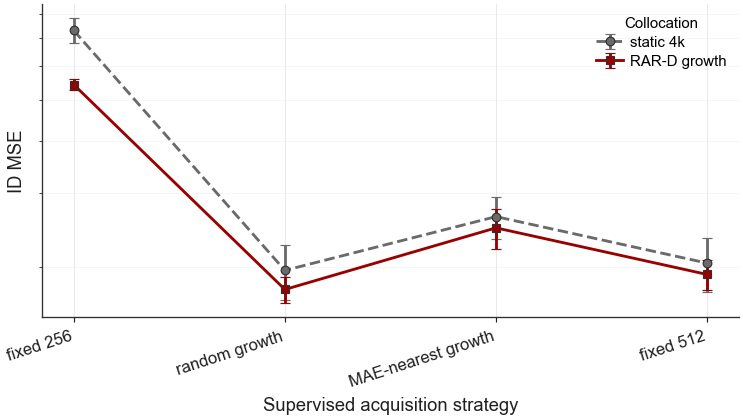

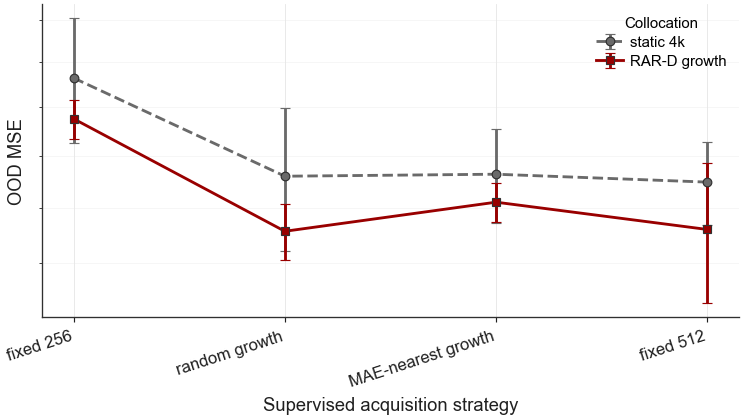

/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/Chapters/6_Results/LR_interaction_id_mse.png
/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/Chapters/6_Results/LR_interaction_ood_mse.png


In [6]:
interaction_metrics = ["best_id_eval_mse", "best_ood_eval_mse"]
interaction_summary = (
    runs.groupby(["supervised_strategy", "collocation_strategy"], observed=True)
    .agg(
        best_id_eval_mse_mean=("best_id_eval_mse", "mean"),
        best_id_eval_mse_std=("best_id_eval_mse", "std"),
        best_ood_eval_mse_mean=("best_ood_eval_mse", "mean"),
        best_ood_eval_mse_std=("best_ood_eval_mse", "std"),
        n_runs=("run_name", "count"),
    )
    .reset_index()
)
interaction_summary["supervised_strategy"] = pd.Categorical(
    interaction_summary["supervised_strategy"].astype(str), categories=SUPERVISED_ORDER, ordered=True
)
interaction_summary["collocation_strategy"] = pd.Categorical(
    interaction_summary["collocation_strategy"].astype(str), categories=COLLOCATION_ORDER, ordered=True
)
interaction_summary = interaction_summary.sort_values(["supervised_strategy", "collocation_strategy"]).reset_index(drop=True)
# Scratch export disabled for repository submission; keep derived data in memory.


def plot_interaction_mse(metric: str, ylabel: str, filename: str):
    fig, ax = plt.subplots(figsize=(6.2, 3.5), constrained_layout=True)
    x = np.arange(len(SUPERVISED_ORDER))
    collocation_colors = {
        "static_low": NEUTRAL_COLORS["muted"],
        "rar_d_growth": DTU_COLORS["corporate_red"],
    }

    for collocation in COLLOCATION_ORDER:
        sub = (
            interaction_summary[interaction_summary["collocation_strategy"].astype(str) == collocation]
            .set_index("supervised_strategy")
            .reindex(SUPERVISED_ORDER)
        )
        means = sub[f"{metric}_mean"].to_numpy(dtype=float)
        std = sub[f"{metric}_std"].to_numpy(dtype=float)
        ax.errorbar(
            x,
            means,
            yerr=np.nan_to_num(std, nan=0.0),
            color=collocation_colors[collocation],
            marker=COLLOCATION_MARKER[collocation],
            linestyle=COLLOCATION_STYLE[collocation],
            linewidth=1.7,
            markersize=5.2,
            markeredgecolor=NEUTRAL_COLORS["axis"],
            markeredgewidth=0.7,
            capsize=3,
            label=collocation_label(collocation),
        )

    ax.set_xticks(x)
    ax.set_xticklabels([supervised_label(strategy) for strategy in SUPERVISED_ORDER], rotation=18, ha="right")
    ax.set_xlabel("Supervised acquisition strategy")
    ax.set_ylabel(ylabel)
    ax.set_yscale("log")
    log_minor_grid(ax, axis="y")
    apply_thesis_axis_style(ax)
    ax.legend(title="Collocation", loc="best")

    output_path = REPO / "Chapters" / "6_Results" / filename
    # Figure export disabled for repository submission; keep plot inline.
    # fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return output_path

id_plot_path = plot_interaction_mse("best_id_eval_mse", "ID MSE", "LR_interaction_id_mse.png")
ood_plot_path = plot_interaction_mse("best_ood_eval_mse", "OOD MSE", "LR_interaction_ood_mse.png")
print(id_plot_path)
print(ood_plot_path)

## Combined ID/OOD Interaction Plot

This version avoids implying a continuous trajectory between categorical acquisition strategies. It combines ID and OOD MSE on one log-scale axis, using color for collocation and marker shape for evaluation split.

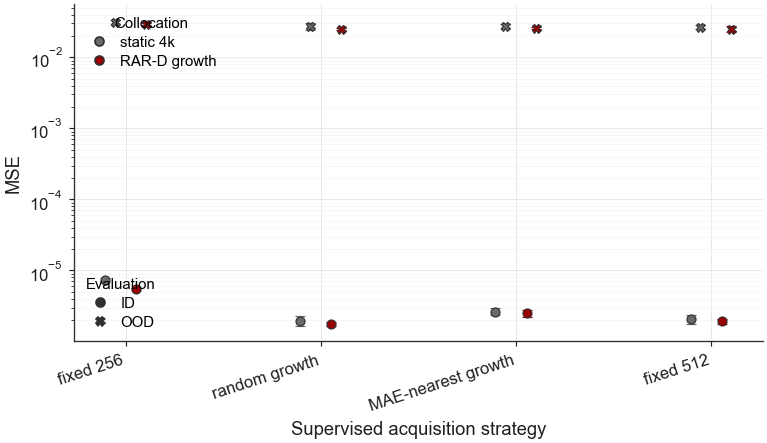

/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/Chapters/6_Results/LR_interaction_mse_combined.png


In [7]:
fig, ax = plt.subplots(figsize=(6.4, 3.7), constrained_layout=True)
x_base = np.arange(len(SUPERVISED_ORDER))
collocation_offsets = {"static_low": -0.08, "rar_d_growth": 0.08}
metric_offsets = {"best_id_eval_mse": -0.025, "best_ood_eval_mse": 0.025}
collocation_colors = {
    "static_low": NEUTRAL_COLORS["muted"],
    "rar_d_growth": DTU_COLORS["corporate_red"],
}
metric_markers = {
    "best_id_eval_mse": "o",
    "best_ood_eval_mse": "X",
}
metric_labels = {
    "best_id_eval_mse": "ID",
    "best_ood_eval_mse": "OOD",
}

for collocation in COLLOCATION_ORDER:
    sub = (
        interaction_summary[interaction_summary["collocation_strategy"].astype(str) == collocation]
        .set_index("supervised_strategy")
        .reindex(SUPERVISED_ORDER)
    )
    for metric in ["best_id_eval_mse", "best_ood_eval_mse"]:
        x = x_base + collocation_offsets[collocation] + metric_offsets[metric]
        means = sub[f"{metric}_mean"].to_numpy(dtype=float)
        std = sub[f"{metric}_std"].to_numpy(dtype=float)
        ax.errorbar(
            x,
            means,
            yerr=np.nan_to_num(std, nan=0.0),
            fmt=metric_markers[metric],
            linestyle="None",
            color=collocation_colors[collocation],
            markeredgecolor=NEUTRAL_COLORS["axis"],
            markeredgewidth=0.7,
            markersize=5.4,
            capsize=3,
            linewidth=1.3,
        )

ax.set_xticks(x_base)
ax.set_xticklabels([supervised_label(strategy) for strategy in SUPERVISED_ORDER], rotation=18, ha="right")
ax.set_xlabel("Supervised acquisition strategy")
ax.set_ylabel("MSE")
ax.set_yscale("log")
log_minor_grid(ax, axis="y")
apply_thesis_axis_style(ax)

collocation_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=collocation_colors[collocation],
        markeredgecolor=NEUTRAL_COLORS["axis"],
        markersize=5.4,
        label=collocation_label(collocation),
    )
    for collocation in COLLOCATION_ORDER
]
metric_handles = [
    plt.Line2D(
        [0], [0],
        marker=metric_markers[metric],
        linestyle="None",
        color=NEUTRAL_COLORS["axis"],
        markeredgecolor=NEUTRAL_COLORS["axis"],
        markersize=5.4,
        label=metric_labels[metric],
    )
    for metric in ["best_id_eval_mse", "best_ood_eval_mse"]
]
legend_collocation = ax.legend(handles=collocation_handles, title="Collocation", loc="upper left")
ax.add_artist(legend_collocation)
ax.legend(handles=metric_handles, title="Evaluation", loc="lower left")

combined_path = REPO / "Chapters" / "6_Results" / "LR_interaction_mse_combined.png"
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()
print(combined_path)

## Grouped ID/OOD MSE Bars

The grouped bar view keeps the categorical design explicit: supervised acquisition strategy is shown on the x-axis and collocation strategy is shown as paired bars.

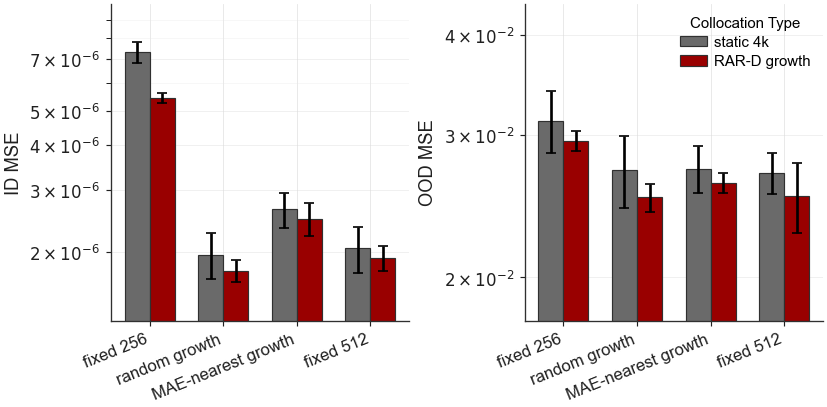

/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/Chapters/6_Results/LR_interaction_mse_bars.png


In [8]:
from matplotlib.ticker import FixedLocator, FuncFormatter, LogLocator, NullFormatter

fig, axes = plt.subplots(1, 2, figsize=(6.9, 3.4), sharex=True, constrained_layout=True)
x = np.arange(len(SUPERVISED_ORDER))
width = 0.34
bar_offsets = {"static_low": -width / 2, "rar_d_growth": width / 2}
bar_colors = {
    "static_low": NEUTRAL_COLORS["muted"],
    "rar_d_growth": DTU_COLORS["corporate_red"],
}
panels = [
    ("best_id_eval_mse", "ID MSE"),
    ("best_ood_eval_mse", "OOD MSE"),
]


def sci_tick(value, _position):
    if value <= 0:
        return ""
    exponent = int(np.floor(np.log10(value)))
    multiplier = value / (10.0 ** exponent)
    if np.isclose(multiplier, 1.0):
        return rf"$10^{{{exponent}}}$"
    return rf"${multiplier:.0f} \times 10^{{{exponent}}}$"


def apply_dense_log_y_ticks(ax, metric: str):
    means = pd.to_numeric(interaction_summary[f"{metric}_mean"], errors="coerce").to_numpy(dtype=float)
    std = pd.to_numeric(interaction_summary[f"{metric}_std"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    finite = np.isfinite(means) & (means > 0)
    if not finite.any():
        return

    lower_values = means[finite] - std[finite]
    lower_values = lower_values[np.isfinite(lower_values) & (lower_values > 0)]
    lower = np.nanmin(lower_values) * 0.78 if len(lower_values) else np.nanmin(means[finite]) * 0.65
    upper = np.nanmax(means[finite] + std[finite]) * 1.28
    ax.set_ylim(lower, upper)

    major_ticks = []
    tick_min = int(np.floor(np.log10(lower)))
    tick_max = int(np.ceil(np.log10(upper)))
    for exponent in range(tick_min, tick_max + 1):
        for multiplier in (1, 2, 3, 4, 5, 7):
            tick = multiplier * 10.0 ** exponent
            if lower <= tick <= upper:
                major_ticks.append(tick)

    ax.yaxis.set_major_locator(FixedLocator(major_ticks))
    ax.yaxis.set_major_formatter(FuncFormatter(sci_tick))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=(3.0, 4.0, 6.0, 7.0, 8.0, 9.0), numticks=50))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis="y", which="minor", length=3.0, width=0.6)
    ax.grid(True, which="major", axis="y", alpha=0.45)
    ax.grid(True, which="minor", axis="y", color=NEUTRAL_COLORS["light_grid"], linewidth=0.35, alpha=0.55)


for ax, (metric, ylabel) in zip(axes, panels):
    for collocation in COLLOCATION_ORDER:
        sub = (
            interaction_summary[interaction_summary["collocation_strategy"].astype(str) == collocation]
            .set_index("supervised_strategy")
            .reindex(SUPERVISED_ORDER)
        )
        means = sub[f"{metric}_mean"].to_numpy(dtype=float)
        std = sub[f"{metric}_std"].to_numpy(dtype=float)
        ax.bar(
            x + bar_offsets[collocation],
            means,
            width=width,
            yerr=np.nan_to_num(std, nan=0.0),
            capsize=3,
            color=bar_colors[collocation],
            edgecolor=NEUTRAL_COLORS["axis"],
            linewidth=0.7,
            label=collocation_label(collocation),
        )
    ax.set_yscale("log")
    apply_dense_log_y_ticks(ax, metric)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([supervised_label(strategy) for strategy in SUPERVISED_ORDER], rotation=22, ha="right")
    apply_thesis_axis_style(ax)

axes[1].legend(title="Collocation Type", loc="upper right")
bar_path = REPO / "Chapters" / "6_Results" / "LR_interaction_mse_bars.png"
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()
print(bar_path)

## Runtime-Performance Trade-Off

The runtime scatter plots compare validation-selected external accuracy against training cost. Points are grouped by collocation strategy and supervised acquisition strategy; error bars show standard deviations across seeds.

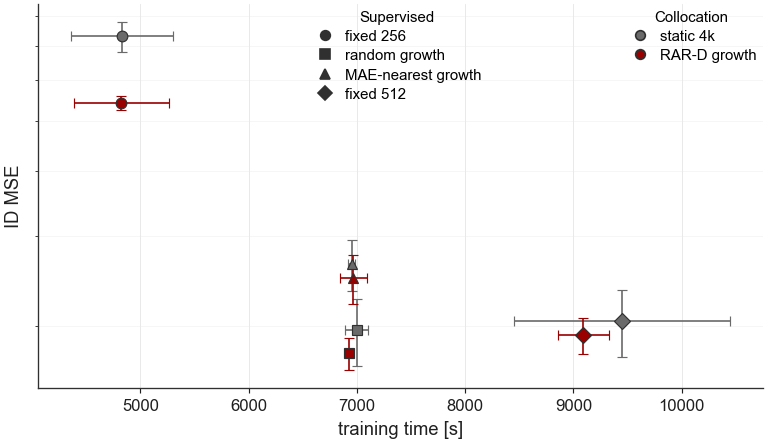

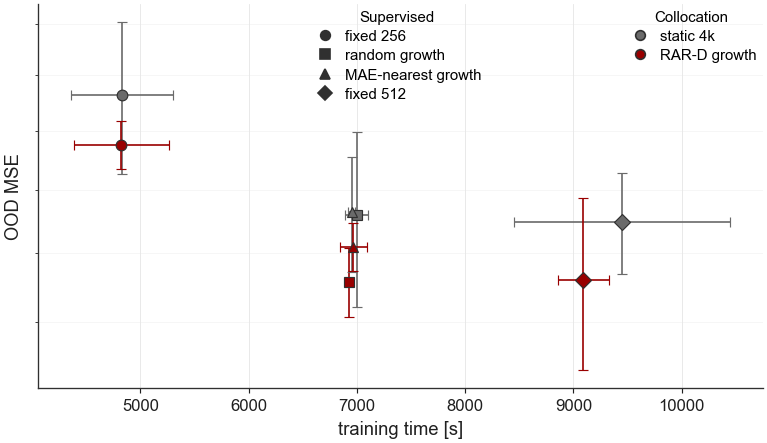

/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/Chapters/6_Results/LR_runtime_vs_id_mse.png
/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/Chapters/6_Results/LR_runtime_vs_ood_mse.png


In [9]:
runtime_summary = (
    runs.groupby(["supervised_strategy", "collocation_strategy"], observed=True)
    .agg(
        training_seconds_mean=("training_seconds", "mean"),
        training_seconds_std=("training_seconds", "std"),
        best_id_eval_mse_mean=("best_id_eval_mse", "mean"),
        best_id_eval_mse_std=("best_id_eval_mse", "std"),
        best_ood_eval_mse_mean=("best_ood_eval_mse", "mean"),
        best_ood_eval_mse_std=("best_ood_eval_mse", "std"),
        n_runs=("run_name", "count"),
    )
    .reset_index()
)
runtime_summary["supervised_strategy"] = pd.Categorical(
    runtime_summary["supervised_strategy"].astype(str), categories=SUPERVISED_ORDER, ordered=True
)
runtime_summary["collocation_strategy"] = pd.Categorical(
    runtime_summary["collocation_strategy"].astype(str), categories=COLLOCATION_ORDER, ordered=True
)
runtime_summary = runtime_summary.sort_values(["supervised_strategy", "collocation_strategy"]).reset_index(drop=True)
# Scratch export disabled for repository submission; keep derived data in memory.

runtime_colors = {
    "static_low": NEUTRAL_COLORS["muted"],
    "rar_d_growth": DTU_COLORS["corporate_red"],
}
supervised_markers = {
    "fixed_low": "o",
    "random_growth": "s",
    "mae_nearest_growth": "^",
    "fixed_final": "D",
}


def plot_runtime_scatter(metric: str, ylabel: str, filename: str):
    fig, ax = plt.subplots(figsize=(6.4, 3.7), constrained_layout=True)
    for _, row in runtime_summary.iterrows():
        supervised = str(row["supervised_strategy"])
        collocation = str(row["collocation_strategy"])
        ax.errorbar(
            row["training_seconds_mean"],
            row[f"{metric}_mean"],
            xerr=0.0 if pd.isna(row["training_seconds_std"]) else row["training_seconds_std"],
            yerr=0.0 if pd.isna(row[f"{metric}_std"]) else row[f"{metric}_std"],
            fmt=supervised_markers[supervised],
            color=runtime_colors[collocation],
            markeredgecolor=NEUTRAL_COLORS["axis"],
            markeredgewidth=0.7,
            markersize=6.4,
            capsize=3,
            linewidth=1.0,
            zorder=3,
        )

    ax.set_xlabel("training time [s]")
    ax.set_ylabel(ylabel)
    ax.set_yscale("log")
    log_minor_grid(ax, axis="y")
    apply_thesis_axis_style(ax)

    collocation_handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color=runtime_colors[collocation],
            markeredgecolor=NEUTRAL_COLORS["axis"],
            markersize=5.8,
            label=collocation_label(collocation),
        )
        for collocation in COLLOCATION_ORDER
    ]
    supervised_handles = [
        plt.Line2D(
            [0], [0],
            marker=supervised_markers[supervised],
            linestyle="None",
            color=NEUTRAL_COLORS["axis"],
            markeredgecolor=NEUTRAL_COLORS["axis"],
            markersize=5.8,
            label=supervised_label(supervised),
        )
        for supervised in SUPERVISED_ORDER
    ]
    legend_collocation = ax.legend(
        handles=collocation_handles,
        title="Collocation",
        loc="upper right",
        bbox_to_anchor=(1.0, 1.0),
        borderaxespad=0.0,
    )
    ax.add_artist(legend_collocation)
    ax.legend(
        handles=supervised_handles,
        title="Supervised",
        loc="upper right",
        bbox_to_anchor=(0.62, 1.0),
        borderaxespad=0.0,
    )

    output_path = REPO / "Chapters" / "6_Results" / filename
    # Figure export disabled for repository submission; keep plot inline.
    # fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return output_path

runtime_id_path = plot_runtime_scatter("best_id_eval_mse", "ID MSE", "LR_runtime_vs_id_mse.png")
runtime_ood_path = plot_runtime_scatter("best_ood_eval_mse", "OOD MSE", "LR_runtime_vs_ood_mse.png")
print(runtime_id_path)
print(runtime_ood_path)

## Worst-Case Prediction Error

The maximum absolute error plots focus on local worst-case behavior under each supervised acquisition and collocation strategy. Error bars are standard deviations across seeds.

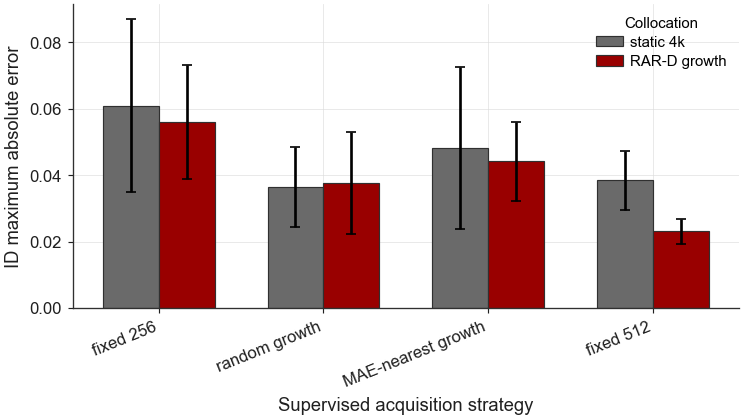

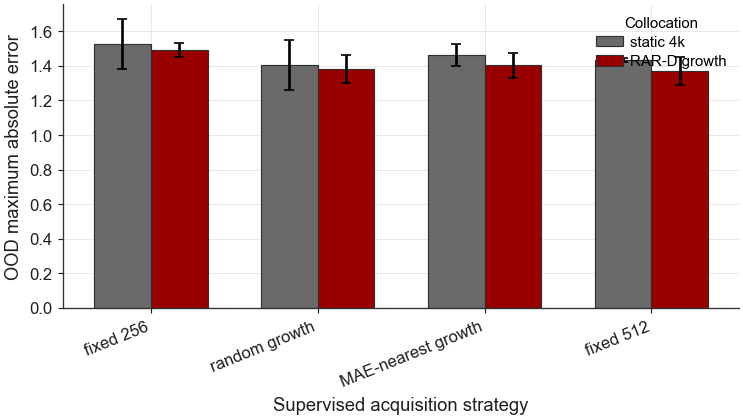

/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/Chapters/6_Results/LR_id_max_error.png
/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/Chapters/6_Results/LR_ood_max_error.png


In [10]:
max_error_summary = (
    runs.groupby(["supervised_strategy", "collocation_strategy"], observed=True)
    .agg(
        best_id_eval_max_abs_error_mean=("best_id_eval_max_abs_error", "mean"),
        best_id_eval_max_abs_error_std=("best_id_eval_max_abs_error", "std"),
        best_ood_eval_max_abs_error_mean=("best_ood_eval_max_abs_error", "mean"),
        best_ood_eval_max_abs_error_std=("best_ood_eval_max_abs_error", "std"),
        n_runs=("run_name", "count"),
    )
    .reset_index()
)
max_error_summary["supervised_strategy"] = pd.Categorical(
    max_error_summary["supervised_strategy"].astype(str), categories=SUPERVISED_ORDER, ordered=True
)
max_error_summary["collocation_strategy"] = pd.Categorical(
    max_error_summary["collocation_strategy"].astype(str), categories=COLLOCATION_ORDER, ordered=True
)
max_error_summary = max_error_summary.sort_values(["supervised_strategy", "collocation_strategy"]).reset_index(drop=True)
# Scratch export disabled for repository submission; keep derived data in memory.

bar_colors = {
    "static_low": NEUTRAL_COLORS["muted"],
    "rar_d_growth": DTU_COLORS["corporate_red"],
}


def plot_max_error_bar(metric: str, ylabel: str, filename: str):
    fig, ax = plt.subplots(figsize=(6.2, 3.5), constrained_layout=True)
    x = np.arange(len(SUPERVISED_ORDER))
    width = 0.34
    offsets = {"static_low": -width / 2, "rar_d_growth": width / 2}
    for collocation in COLLOCATION_ORDER:
        sub = (
            max_error_summary[max_error_summary["collocation_strategy"].astype(str) == collocation]
            .set_index("supervised_strategy")
            .reindex(SUPERVISED_ORDER)
        )
        means = sub[f"{metric}_mean"].to_numpy(dtype=float)
        std = sub[f"{metric}_std"].to_numpy(dtype=float)
        ax.bar(
            x + offsets[collocation],
            means,
            width=width,
            yerr=np.nan_to_num(std, nan=0.0),
            capsize=3,
            color=bar_colors[collocation],
            edgecolor=NEUTRAL_COLORS["axis"],
            linewidth=0.7,
            label=collocation_label(collocation),
        )
    ax.set_xticks(x)
    ax.set_xticklabels([supervised_label(strategy) for strategy in SUPERVISED_ORDER], rotation=22, ha="right")
    ax.set_xlabel("Supervised acquisition strategy")
    ax.set_ylabel(ylabel)
    apply_thesis_axis_style(ax)
    ax.legend(title="Collocation", loc="upper right")

    output_path = REPO / "Chapters" / "6_Results" / filename
    # Figure export disabled for repository submission; keep plot inline.
    # fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return output_path

id_max_error_path = plot_max_error_bar(
    "best_id_eval_max_abs_error",
    "ID maximum absolute error",
    "LR_id_max_error.png",
)
ood_max_error_path = plot_max_error_bar(
    "best_ood_eval_max_abs_error",
    "OOD maximum absolute error",
    "LR_ood_max_error.png",
)
print(id_max_error_path)
print(ood_max_error_path)

## Validation Convergence Under Acquisition

The convergence plot averages validation total loss across seeds for each supervised acquisition strategy, separately for static collocation and RAR-D growth. Curves are smoothed with a 100-epoch rolling median for visualization only.

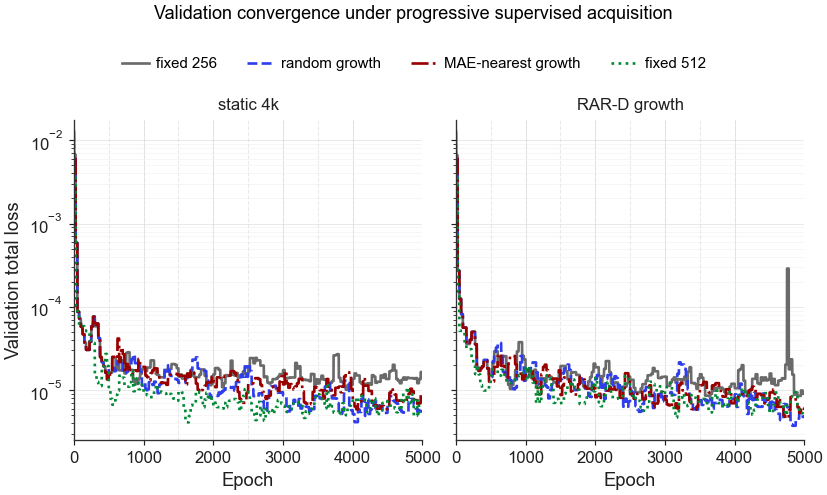

/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/Chapters/6_Results/LR_convergence_acquisition.png


In [11]:
CONVERGENCE_SMOOTH_WINDOW = 100
ACQUISITION_EPOCHS = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000]
CONVERGENCE_COLUMNS = ["global_epoch", "val_total_loss"]

convergence_parts = []
for _, run in runs.iterrows():
    epoch_path = epoch_metrics_path(ROOT, run["batch"], run["run_name"])
    epoch_frame = read_epoch_metrics(epoch_path, columns=CONVERGENCE_COLUMNS)
    if epoch_frame.empty:
        continue
    epoch_frame = epoch_frame.dropna(subset=["global_epoch"]).copy()
    epoch_frame["global_epoch"] = epoch_frame["global_epoch"].astype(int)
    epoch_frame["supervised_strategy"] = str(run["supervised_strategy"])
    epoch_frame["collocation_strategy"] = str(run["collocation_strategy"])
    epoch_frame["seed_label"] = str(run["seed_label"])
    epoch_frame["run_name"] = str(run["run_name"])
    convergence_parts.append(epoch_frame)

if not convergence_parts:
    raise FileNotFoundError("No epoch_metrics.csv files found for local refinement convergence plot.")

convergence_raw = pd.concat(convergence_parts, ignore_index=True, sort=False)
# Scratch export disabled for repository submission; keep derived data in memory.

convergence_mean = (
    convergence_raw
    .groupby(["supervised_strategy", "collocation_strategy", "global_epoch"], observed=True)["val_total_loss"]
    .mean()
    .reset_index()
)

smoothed_parts = []
for (supervised, collocation), sub in convergence_mean.groupby(["supervised_strategy", "collocation_strategy"], observed=True):
    sub = sub.sort_values("global_epoch").copy()
    sub["val_total_loss_smooth"] = (
        sub["val_total_loss"]
        .rolling(CONVERGENCE_SMOOTH_WINDOW, center=True, min_periods=1)
        .median()
    )
    smoothed_parts.append(sub)
convergence_smooth = pd.concat(smoothed_parts, ignore_index=True, sort=False)
convergence_smooth["supervised_strategy"] = pd.Categorical(
    convergence_smooth["supervised_strategy"].astype(str), categories=SUPERVISED_ORDER, ordered=True
)
convergence_smooth["collocation_strategy"] = pd.Categorical(
    convergence_smooth["collocation_strategy"].astype(str), categories=COLLOCATION_ORDER, ordered=True
)
convergence_smooth = convergence_smooth.sort_values(["collocation_strategy", "supervised_strategy", "global_epoch"]).reset_index(drop=True)
# Scratch export disabled for repository submission; keep derived data in memory.

fig, axes = plt.subplots(1, 2, figsize=(6.9, 3.35), sharex=True, sharey=True, constrained_layout=True)
line_styles = {
    "fixed_low": "-",
    "random_growth": "--",
    "mae_nearest_growth": "-.",
    "fixed_final": ":",
}

plot_values = pd.to_numeric(convergence_smooth["val_total_loss_smooth"], errors="coerce").to_numpy(dtype=float)
plot_values = plot_values[np.isfinite(plot_values) & (plot_values > 0)]
if len(plot_values):
    axes[0].set_ylim(max(plot_values.min() * 0.68, 1e-8), plot_values.max() * 1.35)

for ax, collocation in zip(axes, COLLOCATION_ORDER):
    for epoch in ACQUISITION_EPOCHS:
        ax.axvline(epoch, color=NEUTRAL_COLORS["grid"], linestyle="--", linewidth=0.65, alpha=0.58, zorder=0)
    for supervised in SUPERVISED_ORDER:
        sub = convergence_smooth[
            (convergence_smooth["collocation_strategy"].astype(str) == collocation)
            & (convergence_smooth["supervised_strategy"].astype(str) == supervised)
        ]
        if sub.empty:
            continue
        ax.plot(
            sub["global_epoch"],
            sub["val_total_loss_smooth"],
            color=SUPERVISED_COLOR[supervised],
            linestyle=line_styles[supervised],
            linewidth=1.6,
            label=supervised_label(supervised),
        )
    ax.set_title(collocation_label(collocation))
    ax.set_yscale("log")
    ax.set_xlim(0, 5000)
    ax.set_xlabel("Epoch")
    log_minor_grid(ax, axis="y")
    apply_thesis_axis_style(ax)

axes[0].set_ylabel("Validation total loss")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.12), frameon=False)
fig.suptitle("Validation convergence under progressive supervised acquisition", y=1.22)

convergence_path = REPO / "Chapters" / "6_Results" / "LR_convergence_acquisition.png"
# Figure export disabled for repository submission; keep plot inline.
# fig.savefig(convergence_path, dpi=300, bbox_inches="tight")
plt.show()
print(convergence_path)